# UAC Insight: Care Load Dynamics and Seven-Day Forecasting

**Data Science internship project — Harish V J**

Research question: How do reported care loads and flows evolve, and does a seven-day HHS-care model outperform persistence? This notebook preserves the source, validates the observations, builds interpretable indicators, and evaluates models chronologically.

In [1]:
# Locate the project whether this notebook is opened from the root or notebooks/.
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from src.data import read_source
from src.features import derive
from src.analysis import summarize
from src.models import run_experiment, prepare
from scripts.build_project import style, plot_load, plot_flows, plot_models, plot_predictions, plot_sensitivity
style()


## 1. Preserve and audit the source
Only fully blank records are removed. Invalid counts and duplicate dates cause validation to fail instead of being silently repaired. A SHA-256 checksum identifies the exact supplied file.

In [2]:
raw, audit = read_source()
pd.DataFrame([audit]).T.rename(columns={0: 'value'})

,value
filename,HHS_Unaccompanied_Alien_Children_Program.csv
sha256,061af0a97a1b3bda7a36f0ce8df08b6994847b0a4c402828cf2ef835d4947198
source_rows,1170
blank_rows_removed,450
valid_rows,720
invalid_rows,0
duplicate_dates,0
first_date,2023-01-12
last_date,2025-12-21
dataset_fingerprint,5c17d1eb579d538dbae578ee5ddfd7811b09cfd352a4546bde5d0c2a5dabee4b


## 2. Create a canonical analytical table
Stocks and flows retain different meanings. Rolling windows count reported observations. Missing dates are not zero-filled. The first 14-observation indicators remain missing until the complete window exists.

In [3]:
data = derive(raw)
data[['date','hhs_care','total_load','net_flow','gap_days','load_mean7','volatility14']].head(16)

,date,hhs_care,total_load,net_flow,gap_days,load_mean7,volatility14
0,2023-01-12,6566,6619,-402,NaN,NaN,NaN
1,2023-01-22,7122,7171,-188,10.0,NaN,NaN
2,2023-01-23,7280,7330,-142,1.0,NaN,NaN
3,2023-01-24,7433,7475,-128,1.0,NaN,NaN
4,2023-01-25,7538,7560,-139,1.0,NaN,NaN
5,2023-01-29,7472,7517,-292,4.0,NaN,NaN
6,2023-01-30,7743,7797,-167,1.0,7352.714286,NaN
7,2023-01-31,7803,7839,-122,1.0,7527.000000,NaN
8,2023-02-01,7903,7935,-204,1.0,7636.142857,NaN
9,2023-02-02,7879,7892,-275,1.0,7716.428571,NaN


In [4]:
bundle = summarize(raw)
pd.DataFrame([bundle['summary']]).T.rename(columns={0: 'value'})

,value
count,720
calendar_days,1075
unobserved_days,355
coverage_pct,66.98
latest_date,2025-12-21
latest_load,2502
peak_date,2023-12-20
peak_load,11762
change_from_peak_pct,-78.73
transfer_review_count,86


## 3. Explore long-term load and flow patterns
The chart uses actual calendar dates. Lines connect reported endpoints without creating unobserved rows.

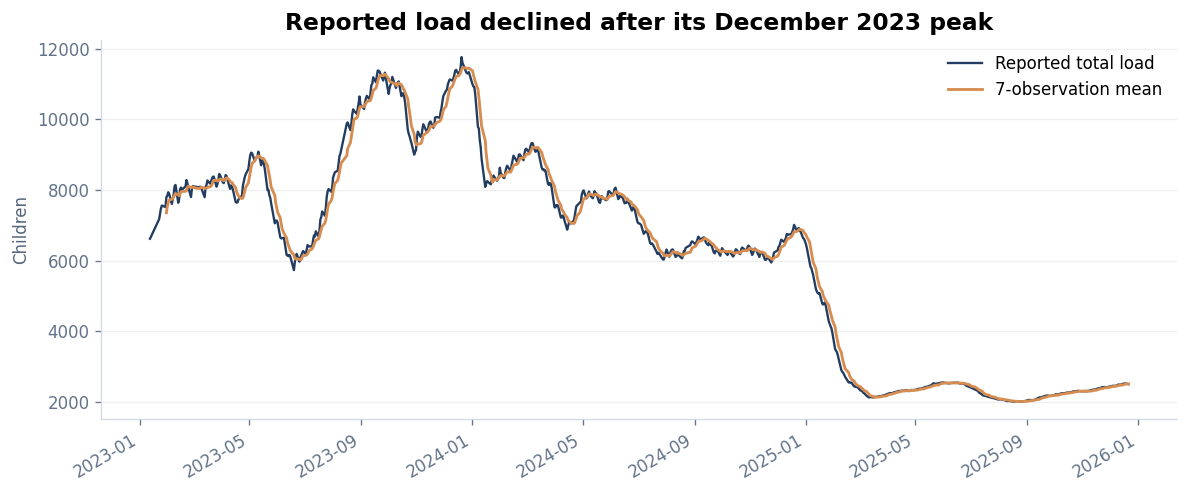

In [5]:
plot_load(data)

In [6]:
pd.DataFrame(bundle['yearly']).rename(columns={'date':'year'})

,year,observations,mean_load,minimum_load,maximum_load,positive_flow_share
0,2023,230,8846.543,5730,11762,5.217
1,2024,251,7319.865,5947,10994,58.964
2,2025,239,2575.745,2002,6471,32.636


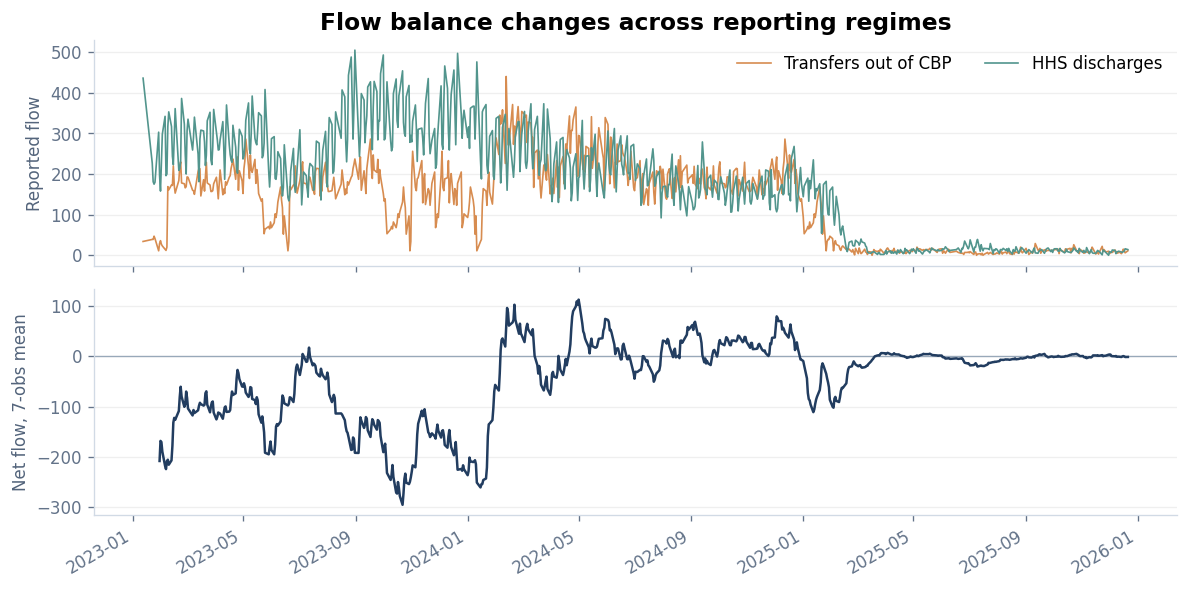

In [7]:
plot_flows(data)

## 4. Test the persistence-rule assumption
A pressure indicator requires a positive rolling net-flow sum and a minimum count of positive observations. Three conventions are compared; none is an official operational threshold.

In [8]:
pd.DataFrame(bundle['sensitivity'])

,rule,flagged,eligible,share_pct
0,3 of 5,223,716,31.15
1,4 of 7,218,714,30.53
2,5 of 7,172,714,24.09


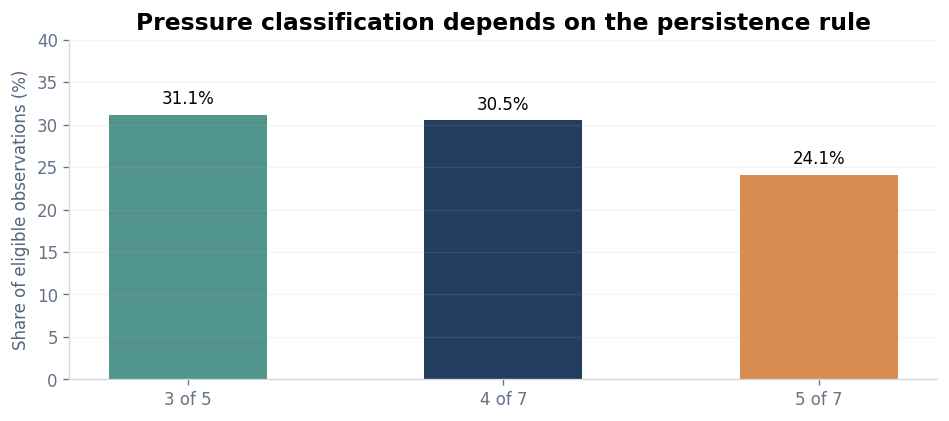

In [9]:
plot_sensitivity(bundle)

## 5. Examine associations cautiously
Rank association describes co-movement. Common trends and time dependence prevent causal interpretation.

In [10]:
data[['cbp_intake','cbp_custody','transfers','hhs_care','discharges','net_flow']].corr(method='spearman').round(3)

,cbp_intake,cbp_custody,transfers,hhs_care,discharges,net_flow
cbp_intake,1.000,0.940,0.865,0.662,0.622,0.049
cbp_custody,0.940,1.000,0.886,0.633,0.596,0.112
transfers,0.865,0.886,1.000,0.657,0.628,0.154
hhs_care,0.662,0.633,0.657,1.000,0.895,-0.463
discharges,0.622,0.596,0.628,0.895,1.000,-0.620
net_flow,0.049,0.112,0.154,-0.463,-0.620,1.000


## 6. Construct exact seven-day targets and evaluate models
An origin is eligible only when HHS care was reported exactly seven calendar days later. Features contain current and earlier values. The 70/15/15 chronological boundaries are applied before fitting; pairs whose targets cross a boundary are excluded. Ridge scaling is fit inside the training pipeline. Validation MAE selects the model, and test data never determine the winner. The candidate configurations are fixed, not optimized against the test set.

In [11]:
experiment = run_experiment(raw)
pd.json_normalize(experiment['scores'])

,model,validation.mae,validation.rmse,validation.bias,test.mae,test.rmse,test.bias
0,Persistence,92.82,154.51,55.01,31.22,34.57,-14.92
1,Local linear trend,86.62,138.45,-49.41,21.91,27.73,-9.96
2,Ridge regression,122.44,145.64,-62.36,66.03,73.29,-37.09
3,Random forest,475.14,492.72,-464.07,27.52,33.72,-23.89


In [12]:
pd.DataFrame([experiment['split']]).T.rename(columns={0:'value'})

,value
validation_start,2025-02-02
test_start,2025-07-16
train_pairs,459
validation_pairs,94
test_pairs,99
train_last_target,2025-01-30
validation_last_target,2025-07-15
test_first_origin,2025-07-16


In [13]:
# Explicit evidence that labels cannot cross into the next partition.
assert experiment['split']['train_last_target'] < experiment['split']['validation_start']
assert experiment['split']['validation_last_target'] < experiment['split']['test_start']
print('Both temporal leakage checks passed.')
print('Chosen on validation:', experiment['selected_model'])
print('Test MAE improvement over persistence:', experiment['test_skill_vs_persistence_pct'], '%')

Both temporal leakage checks passed.
Chosen on validation: Local linear trend
Test MAE improvement over persistence: 29.82 %


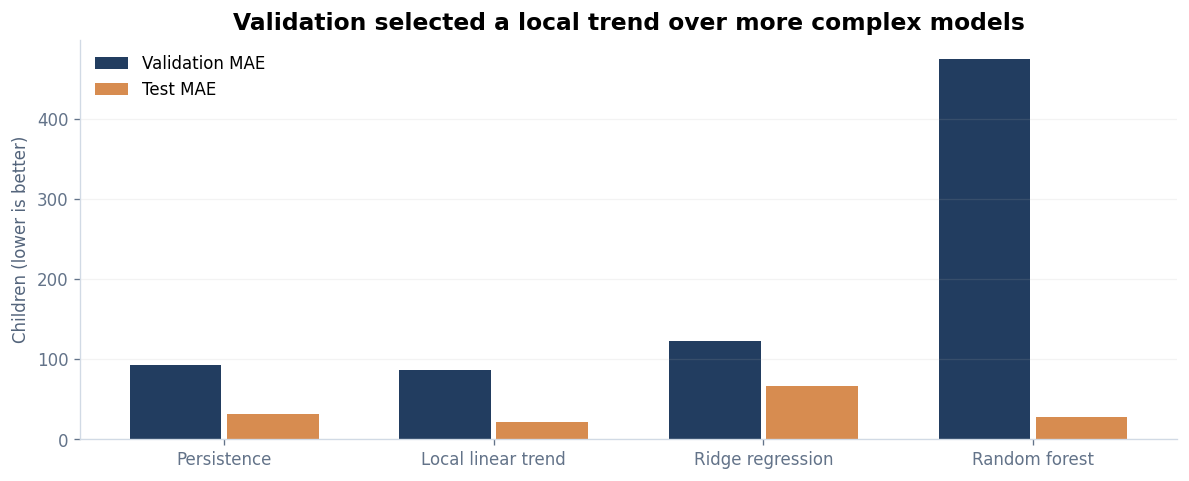

In [14]:
plot_models(experiment)

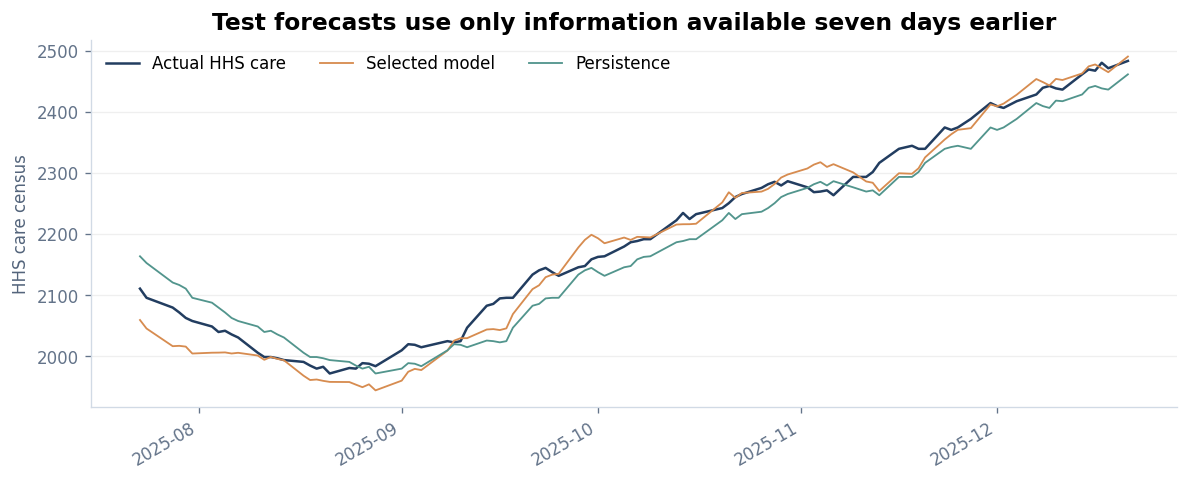

In [15]:
plot_predictions(experiment)

## 7. Interpret a forward estimate from the historical cutoff
This estimate starts at the last supplied observation. It is not a present-day live forecast. The absolute-validation-error reference band is not a calibrated confidence interval.

In [16]:
pd.DataFrame([experiment['forecast']]).T.rename(columns={0:'value'})

,value
origin,2025-12-21
date,2025-12-28
estimate,2513
error_reference_low,2315
error_reference_high,2711
error_radius,198.1


## 8. Conclusions and next steps
The report compares validation and test performance instead of asserting a percentage accuracy. Baseline comparison determines whether model complexity provides value. The dataset supports retrospective load monitoring and flow-pressure indicators, but it does not provide capacity, staffing, or individual-level outcomes.

Future work: acquire defined reporting timestamps and capacity denominators; test additional historical rolling origins; assess stability across regimes; evaluate missing-target selection bias; and monitor drift before operational use.

**Reproduction:** `python scripts/build_project.py` regenerates the numerical tables and figures from the raw CSV. `python -m unittest discover -s tests -v` checks validation, formulas, temporal boundaries, and API workflows.